# Should you only sell when unemployment is rising? 🚦
### "Growth-Trend Timing" — the recession filter for the 200-day moving average, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Skill_beyond_exposure%3F: Mixed](https://img.shields.io/badge/Skill_beyond_exposure%3F-Mixed-8b949e?style=flat-square)

The 200-day moving average is the most famous sell signal in finance: hold stocks while the market is above it, hide in cash when it drops below. It saved you in 2008. It also faked you out **dozens** of times — you sold, the market bounced, you bought back higher. Those fake-outs are called **whipsaws**, and they are the tax trend-followers pay.

In 2016 a widely-read anonymous blogger (*Philosophical Economics*) proposed a fix: the big crashes the 200-day rule protects you from almost all happen in **recessions** — so **only obey the sell signal when the economy is actually deteriorating**. His gauge: is unemployment above its own 12-month average? If the job market is fine, ignore the sell signal and stay invested.

We test it on **77 years** of S&P 500 history. Spoiler: the filter really works — and the honest reason *why* is the best part of the story.

> 📓 **Plain-language layer.** Want the t-stats, the placebo test and the decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Unemployment history is the *revised* modern series, not what investors saw in real time (we do model the one-month publication delay). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from unemployment_trend_timing import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DF = data.load_monthly()
    RACE = st.run_race(DF, cost_bps=5.0)
else:
    DF = RACE = None
print("real GTT cache present:", HAVE_REAL,
      "| months:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1949-02-28', 'end': '2026-06-30', 'months': 928, 'years': 77.3, 'fingerprint': 'a6195d69eb89', 'cost': 5.0, 'race': {'bh': (11.72, 14.46, 0.562, -50.89, 5280), 'faber': (11.21, 10.62, 0.676, -23.26, 3703), 'gtt': (12.59, 12.57, 0.688, -29.55, 9610)}, 'spells': {'faber': (112, 56, 44, 12, 28.6), 'gtt': (60, 30, 16, 14, 13.7)}, 't_pairs': {'gtt_faber': (12.26, 2.32), 'gtt_bh': (4.37, 0.61), 'faber_bh': (-7.9, -0.88)}, 'cost_sweep': [(0, 11.98, 2.28), (5, 12.26, 2.32), (10, 12.54, 2.36), (25, 13.38, 2.49)], 'decomp': {'edge': 12.26, 'share_extra': 14.9, 'mechanical': 10.12, 'timing': 2.15}, 'placebo': {'obs': 12.26, 'mean': 4.69, 'p': 0.0509, 'n': 904}, 'robust': [('6m', 11.93, 2.3), ('12m', 12.26, 2.32), ('24m', 10.76, 1.96), ('price-only', 8.11, 1.52)], 'subperiod': [('pre-2016', 10.46, 1.86, 803), ('post-2016', 27.78, 1.64, 125)], 'bears': [('1974 bear', -11.2, 38.0, 23, 14.8, 12), ('1987 crash', -16.9, -18.5, 5, -16.9, 0), ('2000-02 bust', -25.1, 13.1, 30, -9.2, 25), ('2008 GFC', -22.7, 21.2, 19, 21.2, 19), ('2020 COVID', 18.4, 14.2, 3, 13.0, 1), ('2022 bear', -4.3, -11.6, 9, -4.3, 0)], 'syn': [('planted drag,\nfilter informative', 2.3, 0.022), ('null: filter\nis pure noise', -1.38, 0.988), ('exposure-only\nbait (no drag)', 2.23, 0.586)]}


real GTT cache present: True | months: 928


## The answer first

| Question | Answer |
|---|---|
| Does the filter cut the whipsaws? | **Yes, decisively.** Fake-out exits drop from **44 to 16** (−64%), trades from 112 to 60 — while the big 2008 and dot-com escapes survive. |
| Is filtered timing better than plain timing? | **Yes.** +12 bps/month over the plain 200-day rule across 77 years — statistically solid (*t* ≈ 2.3), and the edge *grows* when trading costs rise, because the filtered rule trades half as much. |
| Is it better than just buying and holding? | **Not provably.** +4 bps/month, *t* = 0.6 — statistical noise. What it does do: $1 → **$9,610** vs $5,280, with a −30% worst fall instead of −51%. |
| What's the catch? | **Two.** Most of the improvement is simply *staying invested more* (the quants notebook proves it), and the filter is **blind to fast crashes**: in 1987 and March 2020, stocks collapsed *before* unemployment moved. |

## 1 · The claim

> *"Trend-following only earns its keep in recessions. Outside recessions its sell signals are whipsaws. So check the economy first: sell only when the market is below its 200-day average **and** unemployment is rising. You'll keep the crash protection and skip half the fake-outs."*

That's **Growth-Trend Timing** (Livingston, *Philosophical Economics*, Feb 2016) — one of the most-cited pieces of post-2008 investment blogging. The base rule it improves is Mebane Faber's famous moving-average strategy, which this desk already graded in [study 110](../../110-faber-timing/README.md): a real drawdown shield that nevertheless lags buy-and-hold on returns. The **filter** is the new claim on trial here.

## 2 · So what?

Millions of retirement dollars follow moving-average rules, and the whipsaw tax is the #1 reason people abandon them. If a public, monthly, free macro number could genuinely cut those fake-outs by half without giving up the crash protection, that's one of the best free lunches in retail investing.

And there's a lovely contrast on this very desk: [study 268](../../268-sahm-rule/README.md) found that unemployment **alone** is a *useless* sell signal (by the time joblessness rises, the crash already happened). GTT uses the same series **not as a trigger but as a veto** on a price signal. Same data, opposite construction — does *that* work?

## 3 · How would we even know?

We race three rules on the same tape — S&P 500 **total return** (price + dividends), 1949–2026, **928 months**, cash earning real T-bill rates, 5 bps cost per switch:

1. **Buy & hold** — never sell.
2. **Faber** — sell when the month ends below the 200-day average; buy back above it.
3. **GTT** — same, but the sell signal only counts if unemployment (as *published*, one month late) is also above its 12-month average.

Every signal is acted on the **following** month (no cheating), and we count every risk-off spell as a **save** (being out dodged losses) or a **whipsaw** (being out cost money).

## 4 · The teardown — let's actually look

**77 years in one picture.** The growth of $1 in each rule, log scale.

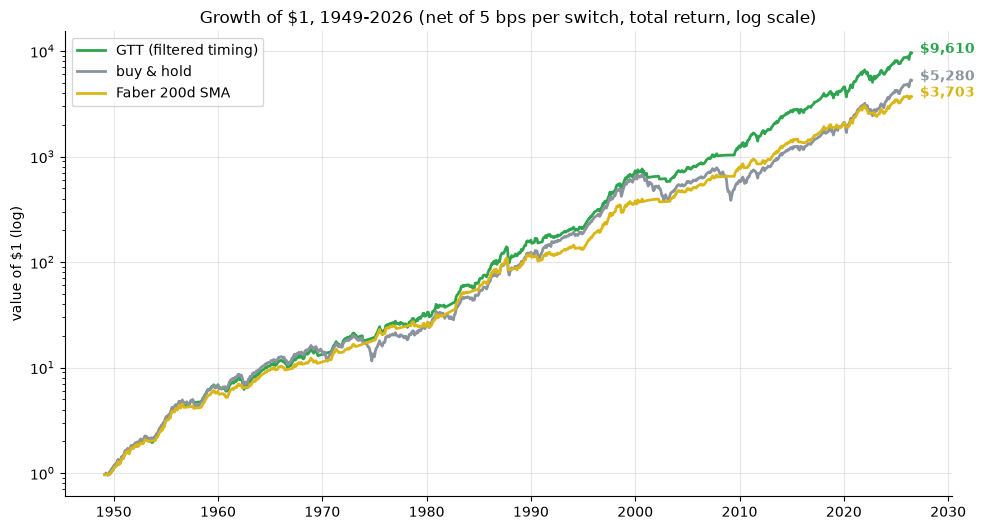

{'bh': '$5,280', 'faber': '$3,703', 'gtt': '$9,610'}


In [2]:
if HAVE_REAL:
    curves = {k: (1 + RACE['series'][k]).cumprod() for k in ('bh','faber','gtt')}
else:
    curves = None
fig, ax = plt.subplots(figsize=(10.0, 5.4))
if curves is not None:
    ax.plot(curves['gtt'], color=GREEN, lw=2, label='GTT (filtered timing)')
    ax.plot(curves['bh'], color=GREY, lw=2, label='buy & hold')
    ax.plot(curves['faber'], color=AMBER, lw=2, label='Faber 200d SMA')
    for k, c in (('gtt', GREEN), ('bh', GREY), ('faber', AMBER)):
        ax.annotate(f"${curves[k].iloc[-1]:,.0f}", (curves[k].index[-1], curves[k].iloc[-1]),
                    color=c, fontweight='bold', xytext=(6, 0), textcoords='offset points')
    ax.set_yscale('log')
    ax.set_title('Growth of $1, 1949-2026 (net of 5 bps per switch, total return, log scale)')
    ax.set_ylabel('value of $1 (log)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print({k: f'${curves[k].iloc[-1]:,.0f}' for k in curves})
else:
    plt.close(fig)
    print('cache missing - frozen numbers:', {k: f'${v[4]:,.0f}' for k, v in R['race'].items()})

GTT turns $1 into **$9,610** vs **$5,280** for buy & hold and **$3,703** for the plain 200-day rule — with a worst fall of **-30%** vs buy & hold's **-51%**. The plain rule protected even better (−23%) but paid for it with the lowest final wealth: its whipsaws ate the compounding.

**The whipsaw count — the heart of the claim.** Every time each rule went to cash, did the exit save money or cost money?

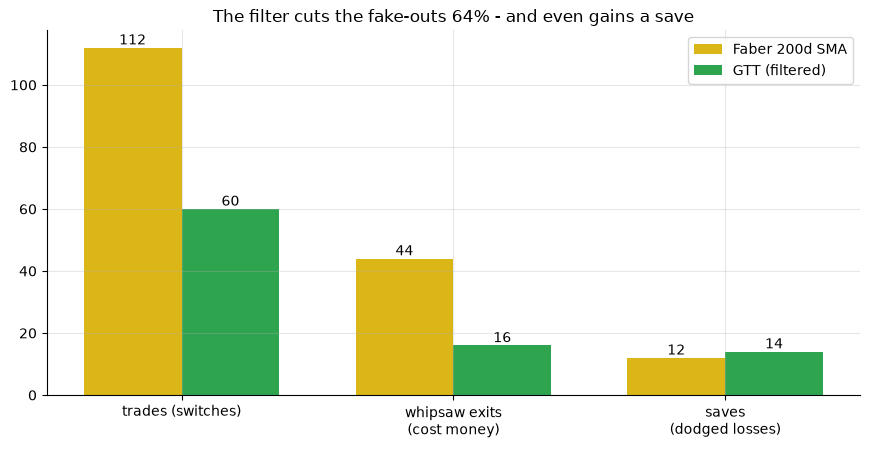

faber (switches, whipsaws, saves): (112, 44, 12)  gtt: (60, 16, 14)


In [3]:
if HAVE_REAL:
    fs, gs = RACE['faber_spells'], RACE['gtt_spells']
    vals = {'faber': (fs['switches'], fs['whipsaws'], fs['saves']),
            'gtt': (gs['switches'], gs['whipsaws'], gs['saves'])}
else:
    vals = {k: (v[0], v[2], v[3]) for k, v in R['spells'].items()}
labs = ['trades (switches)', 'whipsaw exits\n(cost money)', 'saves\n(dodged losses)']
x = np.arange(3); w = 0.36
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.bar(x - w/2, vals['faber'], w, color=AMBER, label='Faber 200d SMA')
ax.bar(x + w/2, vals['gtt'], w, color=GREEN, label='GTT (filtered)')
for i in range(3):
    ax.annotate(str(vals['faber'][i]), (x[i]-w/2, vals['faber'][i]), ha='center', va='bottom')
    ax.annotate(str(vals['gtt'][i]), (x[i]+w/2, vals['gtt'][i]), ha='center', va='bottom')
ax.set_xticks(x); ax.set_xticklabels(labs); ax.legend()
ax.set_title('The filter cuts the fake-outs 64% - and even gains a save')
plt.tight_layout(); plt.show()
print('faber (switches, whipsaws, saves):', vals['faber'], ' gtt:', vals['gtt'])

Whipsaw exits fall from **44** to **16** (−64%) and total trades from **112** to **60** — *more* than the promised halving — while the saves count actually **rises** (14 vs 12): the exits the filter kept were the ones that mattered.

**The six bears, one by one.** Where the filter shines — and where it's blind.

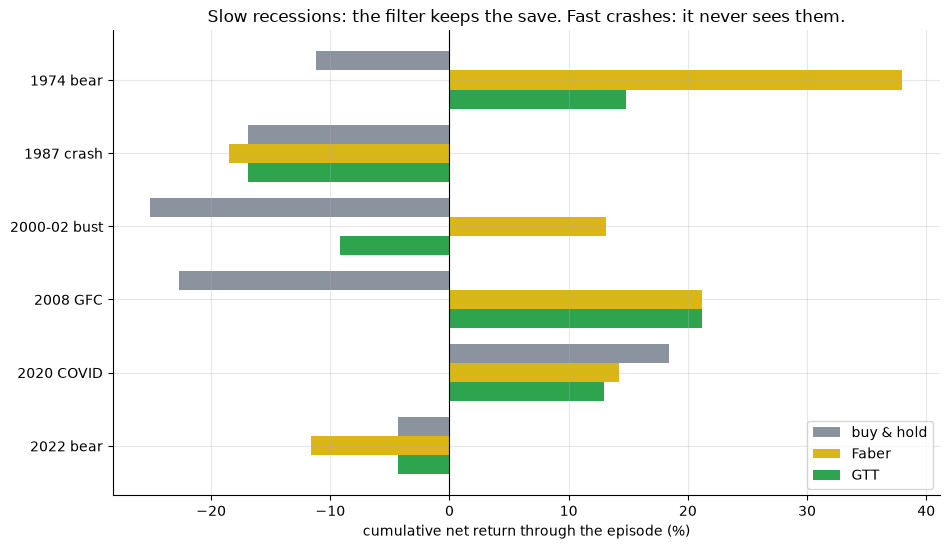

1974 bear      B&H  -11.2%  Faber  +38.0% (out 23m)  GTT  +14.8% (out 12m)
1987 crash     B&H  -16.9%  Faber  -18.5% (out 5m)  GTT  -16.9% (out 0m)
2000-02 bust   B&H  -25.1%  Faber  +13.1% (out 30m)  GTT   -9.2% (out 25m)
2008 GFC       B&H  -22.7%  Faber  +21.2% (out 19m)  GTT  +21.2% (out 19m)
2020 COVID     B&H  +18.4%  Faber  +14.2% (out 3m)  GTT  +13.0% (out 1m)
2022 bear      B&H   -4.3%  Faber  -11.6% (out 9m)  GTT   -4.3% (out 0m)


In [4]:
bears = R['bears']
labs = [b[0] for b in bears]
y = np.arange(len(bears))[::-1]; h = 0.26
fig, ax = plt.subplots(figsize=(9.6, 5.6))
ax.barh(y + h, [b[1] for b in bears], h, color=GREY, label='buy & hold')
ax.barh(y, [b[2] for b in bears], h, color=AMBER, label='Faber')
ax.barh(y - h, [b[4] for b in bears], h, color=GREEN, label='GTT')
ax.axvline(0, color='k', lw=.8)
ax.set_yticks(y); ax.set_yticklabels(labs)
ax.set_xlabel('cumulative net return through the episode (%)')
ax.set_title('Slow recessions: the filter keeps the save. Fast crashes: it never sees them.')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
for b in bears: print(f'{b[0]:14s} B&H {b[1]:+6.1f}%  Faber {b[2]:+6.1f}% (out {b[3]}m)  GTT {b[4]:+6.1f}% (out {b[5]}m)')

Read the two halves:

- **Slow, recessionary bears (1974, 2000-02, 2008):** unemployment was rising, the filter let the sell signal through, and GTT kept most or all of the protection — in 2008 it made **+21%** while the market lost 23%, identical to plain Faber.
- **Fast or job-less bears (1987, 2020, 2022):** unemployment was flat or falling. In 2022 that was *right* — the filter skipped Faber's −11.6% whipsaw entirely. In 1987 and March 2020 it was *wrong* — stocks crashed before the job market moved, and GTT rode the fall fully (its worst drawdown, −29.6%, is dated November 1987).

The filter isn't magic. It's a bet that bear markets announce themselves in the jobless rate first — which is true for recessions, and false for crashes.

## 5 · The verdict

- **Signal — Real.** Over 77 years the filtered rule beat the plain 200-day rule by **+12 bps/month** (*t* ≈ 2.3) with 64% fewer whipsaws — and the edge grows when costs rise, because it trades half as much.
- **Tradability — Fragile.** Anyone can run it with an index fund and a T-bill fund, but the edge over *simply holding* is statistical noise (*t* = 0.6), and the protection fails exactly in fast crashes (1987, 2020).
- **"Skill, or just more market time?" — Mixed.** Here's the honest catch: most of the improvement comes from being *invested more often* (any filter that vetoes half the sell signals collects the market's average reward in those months). The genuinely-smart part — picking *which* signals to veto — is worth about **+2 bps/month** and sits exactly at the edge of statistical significance. The full test is in the quants notebook.

## 6 · Going further 🚪

- **Why this beats using unemployment alone.** [Study 268](../../268-sahm-rule/README.md) showed the jobless rate is a *lagging* sell button — worthless alone. As a **veto** its lag doesn't hurt: it only needs to say "is this dip happening inside a recession?", not "is a crash coming?".
- **The 2020 lesson.** COVID crashed markets in 20 trading days; unemployment printed 4.4% as the market bottomed. Any macro-gated rule inherits this blindness — pair it with an honest expectation: it shields you from 2008s, not from 1987s.
- **Build your own.** Swap the gauge (Sahm spread, industrial production, retail sales), the window (6/12/24 months — all tested in the quants notebook), or the trend rule. The result is stable: real improvement, mostly from staying invested, blind to fast crashes.

*Think the filter's timing is genuinely smart rather than just more market exposure? The quants notebook has a 904-rotation placebo waiting for you — it lands at p = 0.051.*